# 08 - MobileNetV2 Model Training

**Goal:** Build, train, and evaluate a MobileNetV2-based transfer learning model for multi-crop disease detection.

| Phase | Step |
|-------|------|
| 9.1 | Load Dataset |
| 9.2 | Build Data Pipeline |
| 9.3 | Load MobileNetV2 |
| 9.4 | Build Model |
| 9.5 | Compile Model |
| 9.6 | Train Model |
| 9.7 | Save Model |
| 9.8 | Evaluate Model |

| Info | Value |
|------|-------|
| Dataset | PlantVillage (Split) |
| Model | MobileNetV2 (Transfer Learning) |
| Classes | 38 |
| Input Size | 224×224 |

## Phase 9.1 — Load Dataset

In [1]:
# Cell 1 - Import Libraries
import tensorflow as tf
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


In [2]:
# Cell 2 - Dataset Paths
train_dir = "../dataset/train"
val_dir   = "../dataset/val"
test_dir  = "../dataset/test"

print("Train path      :", train_dir)
print("Validation path :", val_dir)
print("Test path       :", test_dir)

Train path      : ../dataset/train
Validation path : ../dataset/val
Test path       : ../dataset/test


In [3]:
# Cell 3 - Image Settings
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

print("Image Size :", IMAGE_SIZE)
print("Batch Size :", BATCH_SIZE)

Image Size : (224, 224)
Batch Size : 32


In [4]:
# Cell 4 - Load Training Dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True
)

Found 37997 files belonging to 38 classes.


In [5]:
# Cell 5 - Load Validation Dataset
validation_dataset = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 8129 files belonging to 38 classes.


In [6]:
# Cell 6 - Load Test Dataset
test_dataset = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

Found 8179 files belonging to 38 classes.


In [7]:
# Cell 7 - Check Classes
class_names = train_dataset.class_names

print("Total Classes:", len(class_names))
print()
for i, name in enumerate(class_names):
    print(f"  {i+1:>2}. {name}")

Total Classes: 38

   1. Apple___Apple_scab
   2. Apple___Black_rot
   3. Apple___Cedar_apple_rust
   4. Apple___healthy
   5. Blueberry___healthy
   6. Cherry_(including_sour)___Powdery_mildew
   7. Cherry_(including_sour)___healthy
   8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   9. Corn_(maize)___Common_rust_
  10. Corn_(maize)___Northern_Leaf_Blight
  11. Corn_(maize)___healthy
  12. Grape___Black_rot
  13. Grape___Esca_(Black_Measles)
  14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
  15. Grape___healthy
  16. Orange___Haunglongbing_(Citrus_greening)
  17. Peach___Bacterial_spot
  18. Peach___healthy
  19. Pepper,_bell___Bacterial_spot
  20. Pepper,_bell___healthy
  21. Potato___Early_blight
  22. Potato___Late_blight
  23. Potato___healthy
  24. Raspberry___healthy
  25. Soybean___healthy
  26. Squash___Powdery_mildew
  27. Strawberry___Leaf_scorch
  28. Strawberry___healthy
  29. Tomato___Bacterial_spot
  30. Tomato___Early_blight
  31. Tomato___Late_blight
  32. Toma

In [8]:
# Cell 8 - Show Dataset Information
print("=" * 45)
print("Dataset Summary")
print("=" * 45)
print(f"Training Batches   : {len(train_dataset)}")
print(f"Validation Batches : {len(validation_dataset)}")
print(f"Test Batches       : {len(test_dataset)}")
print(f"Batch Size         : {BATCH_SIZE}")
print(f"Image Size         : {IMAGE_SIZE}")
print(f"Total Classes      : {len(class_names)}")
print("=" * 45)

Dataset Summary
Training Batches   : 1188
Validation Batches : 255
Test Batches       : 256
Batch Size         : 32
Image Size         : (224, 224)
Total Classes      : 38


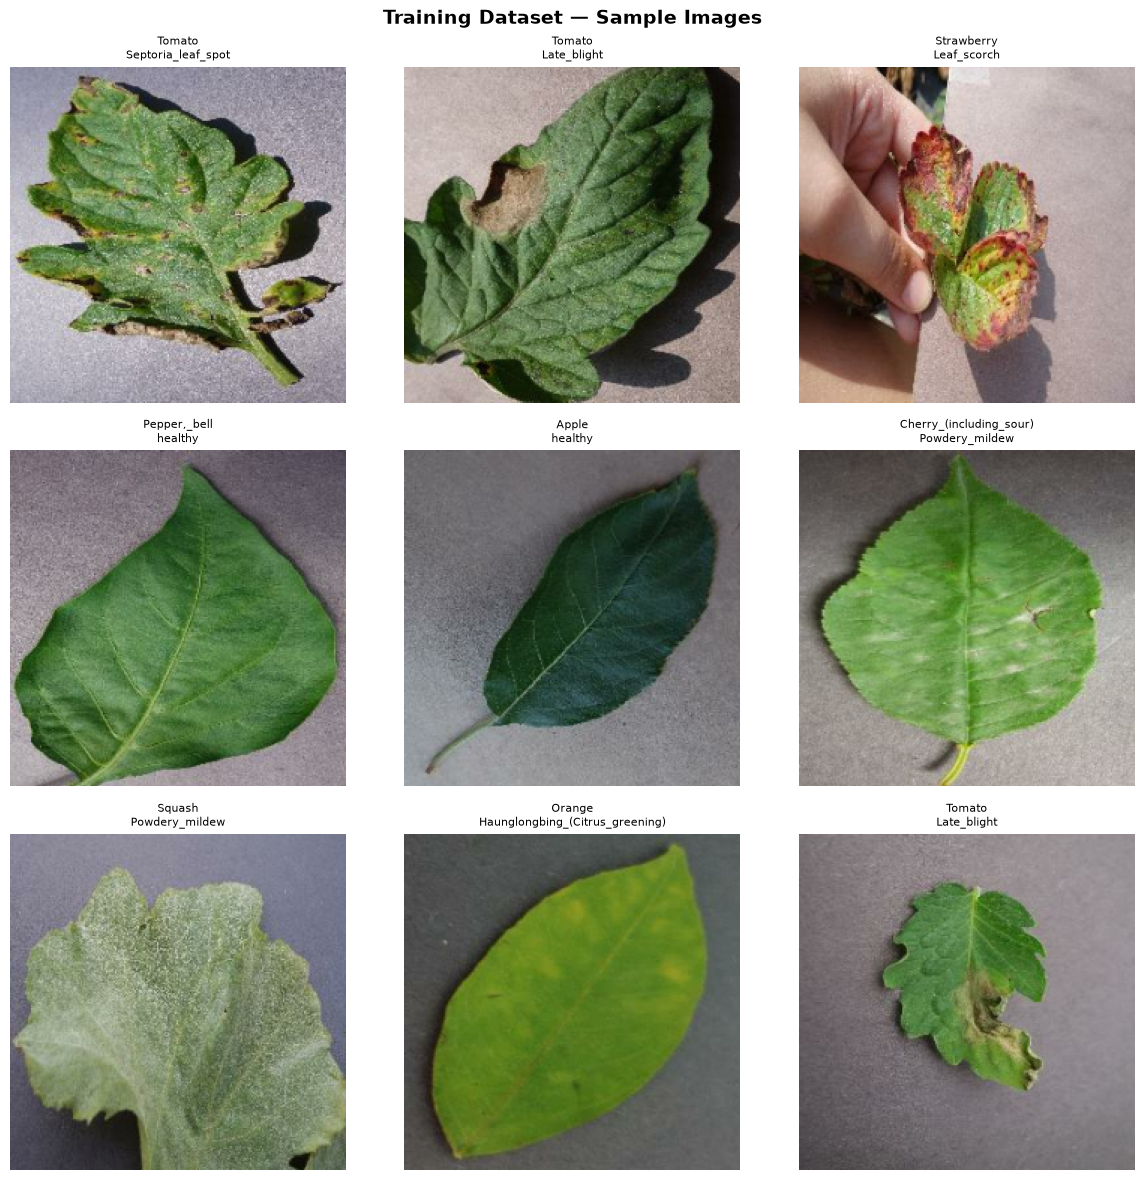


✅ Phase 9.1 Complete — Dataset loaded successfully!
✅ Ready for Phase 9.2 — Build Data Pipeline


In [9]:
# Cell 9 - Display Sample Images from Training Set
plt.figure(figsize=(12, 12))

for images, labels in train_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        class_label = class_names[tf.argmax(labels[i])]
        crop, condition = class_label.split("___") if "___" in class_label else (class_label, "")
        plt.title(f"{crop}\n{condition}", fontsize=8)
        plt.axis("off")

plt.suptitle("Training Dataset — Sample Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("sample_training_images.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n✅ Phase 9.1 Complete — Dataset loaded successfully!")
print("✅ Ready for Phase 9.2 — Build Data Pipeline")

## Phase 9.2 — Build Data Pipeline

In [10]:
# Cell 10 - Cache Dataset (Disabled training cache to prevent RAM crash)
# train_dataset = train_dataset.cache()
# validation_dataset = validation_dataset.cache()
# test_dataset = test_dataset.cache()

print("Caching disabled on datasets to save RAM")

Caching disabled on datasets to save RAM


In [11]:
# Cell 11 - Enable Prefetch
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch(buffer_size=AUTOTUNE)
validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch(buffer_size=AUTOTUNE)

print("Prefetch enabled on datasets using AUTOTUNE")

Prefetch enabled on datasets using AUTOTUNE


In [12]:
# Cell 12 - Verify Pipeline
print(train_dataset)
print(validation_dataset)
print(test_dataset)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>
<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 38), dtype=tf.float32, name=None))>


## Phase 9.3 — Load MobileNetV2 (Transfer Learning)

**Goal:** Load the pre-trained MobileNetV2 model with weights trained on the ImageNet dataset, freeze its weights, and verify its structure.

In [13]:
# Cell 13 - Import Keras Application Modules
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers
from tensorflow.keras import models

In [14]:
# Cell 14 - Load Pre-trained MobileNetV2 Base Model
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

In [15]:
# Cell 15 - Freeze Base Model Weights
base_model.trainable = False

In [16]:
# Cell 16 - Verify Base Model Structure and Trainable Parameters
base_model.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Phase 9.4 — Build Classification Head

**Goal:** Build a custom classification head on top of the frozen MobileNetV2 base model using Global Average Pooling, Dropout, and Dense layers.

In [17]:
# Cell 17 - Build classification head on top of base model
model = models.Sequential([
    # Rescale inputs from [0, 255] to [-1, 1] for MobileNetV2
    layers.Rescaling(1./127.5, offset=-1.0),

    # Pretrained MobileNetV2
    base_model,

    # Convert feature maps to a vector
    layers.GlobalAveragePooling2D(),

    # Prevent overfitting
    layers.Dropout(0.3),

    # Hidden layer
    layers.Dense(128, activation="relu"),

    # Extra dropout
    layers.Dropout(0.2),

    # Output layer (38 disease classes)
    layers.Dense(38, activation="softmax")
])

In [18]:
# Cell 18 - Print Complete Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

## Phase 9.5 — Compile Model

**Goal:** Compile the model using the Adam optimizer, categorical crossentropy loss, and accuracy metrics to configure it for training.

In [19]:
# Cell 19 - Import Adam Optimizer
from tensorflow.keras.optimizers import Adam

In [20]:
# Cell 20 - Compile Model
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [21]:
# Cell 21 - Check Compilation Success
print("✅ Model Compiled Successfully!")

✅ Model Compiled Successfully!


## Phase 9.6 — Model Training

**Goal:** Configure callbacks (ModelCheckpoint, EarlyStopping, ReduceLROnPlateau) and train the model.

In [22]:
# Cell 22 - Import Callbacks for Training Optimization
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau
)

In [23]:
# Cell 23 - Configure Model Checkpoint Callback
checkpoint = ModelCheckpoint(
    filepath="../models/best_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

In [24]:
# Cell 24 - Configure Early Stopping Callback
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [25]:
# Cell 25 - Configure Learning Rate Reduction Callback
reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

In [26]:
# Cell 26 - Train the Model
EPOCHS = 10

history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    validation_data=validation_dataset,
    callbacks=[checkpoint, early_stop, reduce_lr]
)

Epoch 1/10


c:\Users\DELL\Documents\5th semester\PROJECTS\AI-Powered-Multi-Crop-Disease-Detection-Platform-for-Smart-Agriculture\venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.5954 - loss: 1.5559
Epoch 1: val_accuracy improved from None to 0.86198, saving model to ../models/best_model.keras

Epoch 1: finished saving model to ../models/best_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1465s 1s/step - accuracy: 0.5954 - loss: 1.5559 - val_accuracy: 0.8620 - val_loss: 0.5593 - learning_rate: 1.0000e-04
Epoch 2/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8147 - loss: 0.6322
Epoch 2: val_accuracy improved from 0.86198 to 0.90761, saving model to ../models/best_model.keras

Epoch 2: finished saving model to ../models/best_model.keras
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 1472s 1s/step - accuracy: 0.8147 - loss: 0.6322 - val_accuracy: 0.9076 - val_loss: 0.3398 - learning_rate: 1.0000e-04
Epoch 3/10
1188/1188 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8594 - loss: 0.4584
Epoch 3: val_accuracy improved from 0.90761 to 0.92398, saving model to ../models/best_model.keras

Epoch 3: finished saving model to

## Phase 9.7 — Evaluate Model

**Goal:** Evaluate the model performance on the unseen test dataset.

In [ ]:
# Cell 27 - Evaluate on Test Dataset
test_loss, test_accuracy = model.evaluate(test_dataset)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

## Phase 9.8 — Visualize Training Results

**Goal:** Plot and save the training and validation accuracy/loss curves.

In [ ]:
# Cell 28 - Plot and Save Training History Graphs
import os
import matplotlib.pyplot as plt

# Ensure results directory exists
os.makedirs("../results", exist_ok=True)

# 1. Plot & Save Accuracy Graph
plt.figure(figsize=(10, 6))
plt.plot(history.history["accuracy"], label="Training Accuracy", marker='o')
plt.plot(history.history["val_accuracy"], label="Validation Accuracy", marker='o')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.savefig("../results/accuracy_graph.png", dpi=150, bbox_inches='tight')
plt.show()

# 2. Plot & Save Loss Graph
plt.figure(figsize=(10, 6))
plt.plot(history.history["loss"], label="Training Loss", marker='o')
plt.plot(history.history["val_loss"], label="Validation Loss", marker='o')
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig("../results/loss_graph.png", dpi=150, bbox_inches='tight')
plt.show()

print("✅ Training graphs saved successfully in '../results/' directory!")

## Phase 9.9 — Save the Final Model

**Goal:** Permanently save the final trained model for use in the backend API.

In [30]:
# Cell 29 - Save the Model
import os
os.makedirs("../models", exist_ok=True)
model.save("../models/final_model.keras")
print("✅ Final model saved to ../models/final_model.keras")

✅ Final model saved to ../models/final_model.keras


In [31]:
# Cell 30 - Check Model File Existence
import os
print("Model file exists:", os.path.exists("../models/final_model.keras"))

Model file exists: True


# Phase 10 — Image Prediction System

**Goal:** Build a utility function to load the saved model, preprocess an external leaf image, predict the crop disease, and display the confidence score.

### Phase 10.1 — Load Saved Model

In [32]:
# Cell 31 - Load the permanent model
from tensorflow.keras.models import load_model

model_path = "../models/final_model.keras"
loaded_model = load_model(model_path)
print(f"✅ Model loaded successfully from {model_path}!")

✅ Model loaded successfully from ../models/final_model.keras!


### Phase 10.2 & 10.3 — Image Preprocessing and Prediction Function

Create a helper function to read a leaf image, resize it to 224x224, convert color format, expand dimensions, and make predictions.

In [33]:
# Cell 32 - Prediction Helper Function
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

def predict_leaf_disease(image_path, model, class_names):
    # Read the image using OpenCV
    img_bgr = cv2.imread(image_path)
    if img_bgr is None:
        print(f"❌ Error: Could not read image at {image_path}")
        return
    
    # Convert BGR to RGB (OpenCV reads in BGR by default)
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    
    # Resize to 224x224 (as expected by MobileNetV2)
    img_resized = cv2.resize(img_rgb, (224, 224))
    
    # Expand dimensions to create a batch (1, 224, 224, 3)
    img_batch = np.expand_dims(img_resized, axis=0)
    
    # Predict using the loaded model
    predictions = model.predict(img_batch)
    
    # Get predicted class index and confidence
    pred_idx = np.argmax(predictions[0])
    confidence = predictions[0][pred_idx] * 100
    predicted_class = class_names[pred_idx]
    
    # Format class name (crop ___ condition -> crop, condition)
    crop, condition = predicted_class.split("___") if "___" in predicted_class else (predicted_class, "")
    
    # Plot the image and prediction results
    plt.figure(figsize=(6, 6))
    plt.imshow(img_rgb)
    plt.title(f"Crop: {crop}\nCondition: {condition}\nConfidence: {confidence:.2f}%", fontsize=12, color="blue")
    plt.axis("off")
    plt.show()
    
    return crop, condition, confidence

### Phase 10.4 & 10.5 — Test Single Prediction

Test the system on a random image from the test directory.

Selected test image: ../dataset/test\Corn_(maize)___Northern_Leaf_Blight\3a0c570b-dfd1-4681-97be-658151e7279f___RS_NLB 4099.JPG
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step


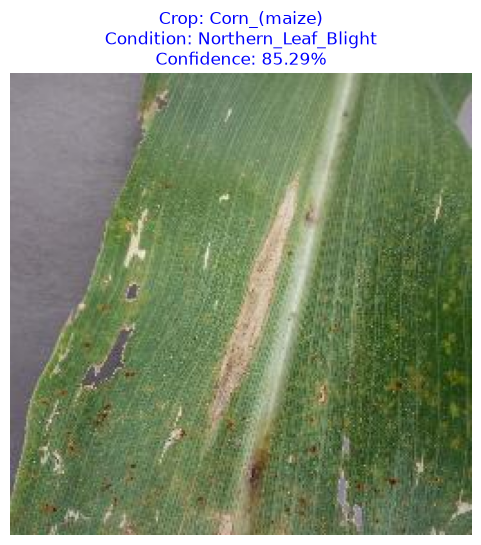

In [36]:
# Cell 33 - Test Prediction on a random image from Test Directory
import glob
import random

# Get list of all images in test set
test_images = glob.glob("../dataset/test/**/*.jpg", recursive=True) + glob.glob("../dataset/test/**/*.png", recursive=True)

if len(test_images) > 0:
    # Select a random test image
    random_image_path = random.choice(test_images)
    print(f"Selected test image: {random_image_path}")
    
    # Run prediction
    predict_leaf_disease(random_image_path, loaded_model, class_names)
else:
    print("⚠ No test images found in '../dataset/test/' directory to run prediction testing.")